In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler 
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn import linear_model

In [2]:
class FIFA_EDA():
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None

    def load_data(self):
        try:
            self.data = pd.read_csv(self.file_path)
            print(self.data.head())
            return self.data
        except Exception as error:
            print(f"Error loading data: {error}")
            return None
        

    def check_missing_values(self):
        print("duplicate rows found :", self.data.duplicated().sum())
        print("Missing Values Analysis :")
        missing = self.data.isnull().sum()
        print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
        print("-" * 30)

    def analyze_value_distribution(self):
        print("Distribution of Value Per M$ :")
        plt.figure(figsize=(10, 5))
        sns.histplot(np.log1p(self.data['Value Per M$']), kde=True, color='teal')
        plt.xlabel('Log of Value Per M$')
        
        skewness = self.data['Value Per M$'].skew()
        plt.title(f'Value Distribution (Skewness: {skewness:.2f})')
        plt.show()
        
        if skewness > 1:
            print(f"The distribution is Highly Right-Skewed (Skewness: {skewness:.2f})")
        elif skewness < -1:
            print(f"The distribution is Highly Left-Skewed (Skewness: {skewness:.2f})")
        else:
            print(f"The distribution is approximately Normal (Skewness: {skewness:.2f})")

    def numerical_correlation(self):
        print("Numerical Features Related to Value :")
        numeric_data = self.data.select_dtypes(include=[np.number])
        correlation = numeric_data.corr()['Value Per M$'].sort_values(ascending=False)
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
        plt.title("Feature Correlation Matrix")
        plt.show()
        
        print("Correlation with Value Per M$:\n", correlation)

    def average_rating_by_position(self):
        print("Average Overall Rating per Position :")
        avg_rating = self.data.groupby('Position')['Overall_Rating'].mean().sort_values(ascending=False)
        
        plt.figure(figsize=(12, 5))
        avg_rating.plot(kind='bar', color='skyblue')
        plt.ylabel('Average Overall Rating')
        plt.title('Average Rating by Position')
        plt.show()
        print(avg_rating)

In [3]:
class FIFA_Preprocessing(FIFA_EDA):
    def __init__(self, file_path, target_col='Value Per M$', task_type='regression'):
        super().__init__(file_path)
        self.target_col = target_col
        self.task_type = task_type.lower()

    def prepare_data(self):
        df = self.data.copy()
        
        if 'Name' in df.columns:
            df = df.drop(columns=['Name'])

        # ---------------------------------------------------------
        # BRANCH A: REGRESSION (Your Original Logic)
        # ---------------------------------------------------------
        if self.task_type == 'regression':
            X = df.drop(columns=[self.target_col])
            y = df[self.target_col]

            # Split FIRST to prevent leakage
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            # Target Encoding
            for col in ['Country', 'Team', 'Position']:
                if col in X_train.columns:
                    target_means = X_train.assign(Target=y_train).groupby(col)['Target'].mean()
                    global_mean = y_train.mean()
                    X_train[col] = X_train[col].map(target_means).fillna(global_mean)
                    X_test[col] = X_test[col].map(target_means).fillna(global_mean)

            # Outlier Handling
            standard_num_cols = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score']
            for col in standard_num_cols:
                if col in X_train.columns:
                    Q1 = X_train[col].quantile(0.25)
                    Q3 = X_train[col].quantile(0.75)
                    IQR = Q3 - Q1
                    lower = Q1 - 1.5 * IQR
                    upper = Q3 + 1.5 * IQR
                    X_train[col] = np.clip(X_train[col], lower, upper)
                    X_test[col] = np.clip(X_test[col], lower, upper)

            # Scaling
            scaler = MinMaxScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
            X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

            print("✅ Regression Preprocessing Complete: Target Encoded, Outliers Capped, Scaled.")
            return X_train, X_test, y_train, y_test

        # ---------------------------------------------------------
        # BRANCH B: CLASSIFICATION (For Task 6)
        # ---------------------------------------------------------
        elif self.task_type == 'classification':
            # Create Tier Binning and prevent target leakage
            if self.target_col == 'Performance_Tier' and 'Overall_Rating' in df.columns:
                df['Performance_Tier'] = pd.qcut(df['Overall_Rating'], q=3, labels=['Low', 'Medium', 'High'])
                df = df.drop(columns=['Overall_Rating', 'Value Per M$'])

            y = df[self.target_col]
            X = df.drop(columns=[self.target_col])

            # Apply One-Hot Encoding
            X = pd.get_dummies(X, columns=['Country', 'Position', 'Team'], drop_first=True)

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            # Scale Numericals (ComplementNB requires non-negative values)
            scaler = MinMaxScaler()
            num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
            X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
            X_test[num_cols] = scaler.transform(X_test[num_cols])

            print("✅ Classification Preprocessing Complete: Binned Target, OHE applied, Leakage prevented.")
            return X_train, X_test, y_train, y_test

                 Name Country Position  Age  Overall_Rating  Future Potential  \
0  Agostinho Mabululu  Angola       LW   30              68                68   
1     Mahmoud Gennesh   Egypt       GK   35              67                67   
2      Sobhi Suleiman   Egypt       GK   28              63                65   
3        Mahmoud Alaa   Egypt       CB   32              68                68   
4     Mahmoud Shabana   Egypt       CB   30              66                66   

                 Team  Value Per M$  Total_Stats Score  
0  Ittihad Alexandria          0.65               1660  
1  Ittihad Alexandria          0.35               1620  
2  Ittihad Alexandria          0.20               1480  
3  Ittihad Alexandria          0.50               1695  
4  Ittihad Alexandria          0.40               1640  
duplicate rows found : 0
Missing Values Analysis :
No missing values found.
------------------------------
Distribution of Value Per M$ :


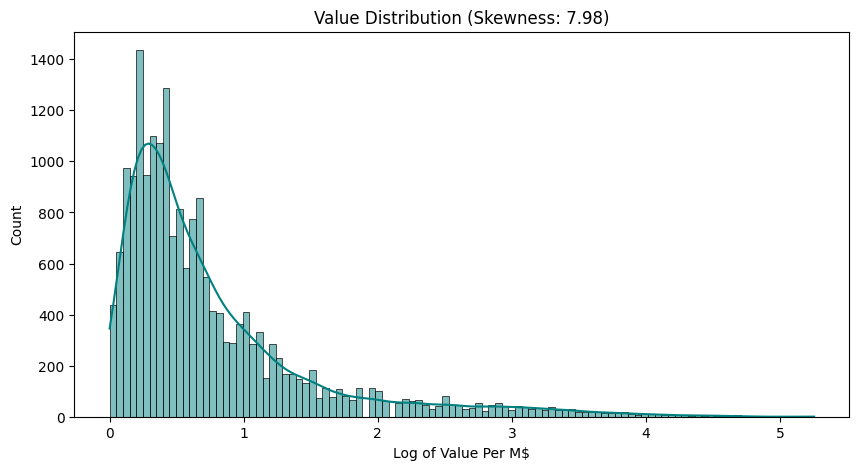

The distribution is Highly Right-Skewed (Skewness: 7.98)
Numerical Features Related to Value :


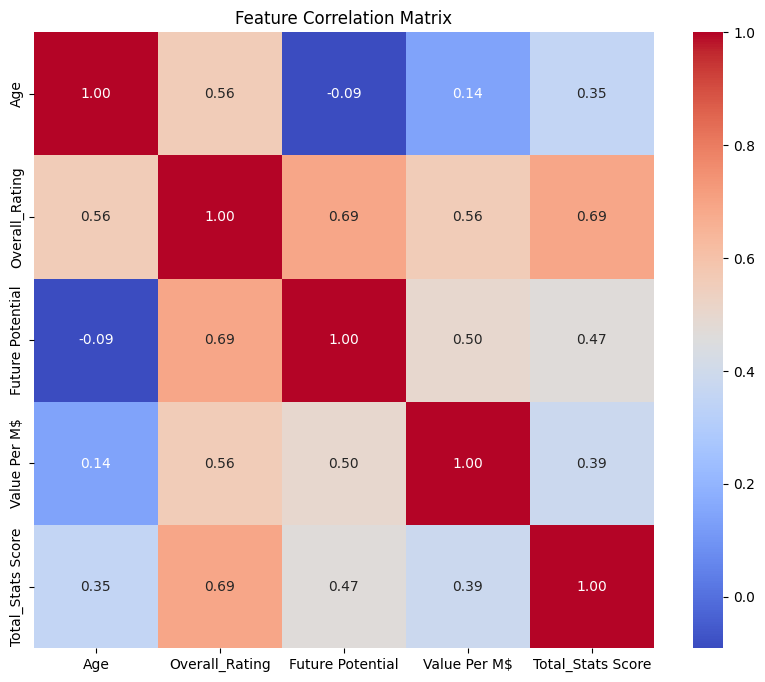

Correlation with Value Per M$:
 Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64
Average Overall Rating per Position :


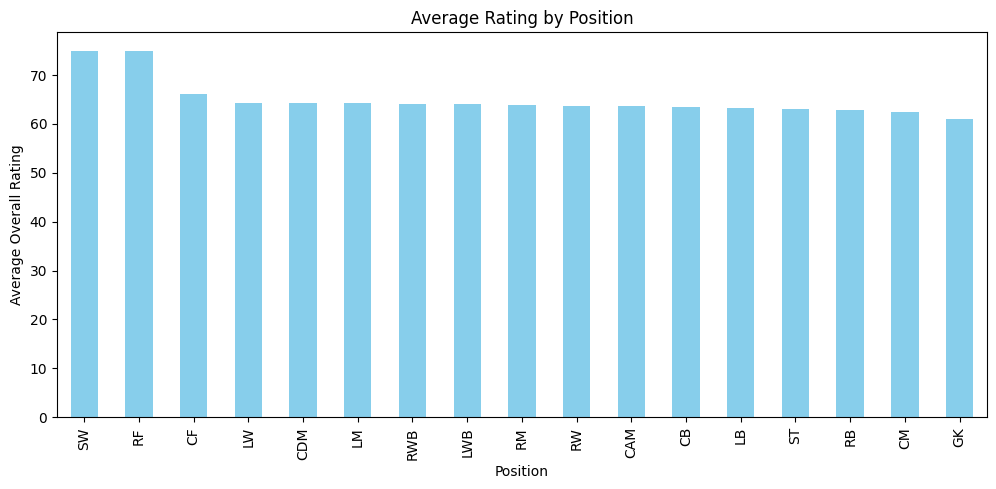

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64
✅ Regression Preprocessing Complete: Target Encoded, Outliers Capped, Scaled.

Regression Training set shape: (15733, 7)


In [4]:
file_path = 'Fifa.csv'

eda = FIFA_Preprocessing(file_path, target_col='Value Per M$', task_type='regression')
data = eda.load_data()

if data is not None:
    eda.check_missing_values()
    eda.analyze_value_distribution()
    eda.numerical_correlation()
    eda.average_rating_by_position()

    # Prepares Regression Data
    X_train_reg, X_test_reg, y_train_reg, y_test_reg = eda.prepare_data()
    print(f"\nRegression Training set shape: {X_train_reg.shape}")

--- Class Distribution after Splitting ---
Training Set:
 Overall_Rating
Low      4403
Mid      4117
Elite    3753
High     3460
Name: count, dtype: int64

Testing Set:
 Overall_Rating
Low      1165
Mid       985
Elite     947
High      837
Name: count, dtype: int64


C:\Users\Hello\AppData\Local\Temp\ipykernel_14624\2100795742.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_tier, order=['Low', 'Mid', 'High', 'Elite'], palette='viridis')


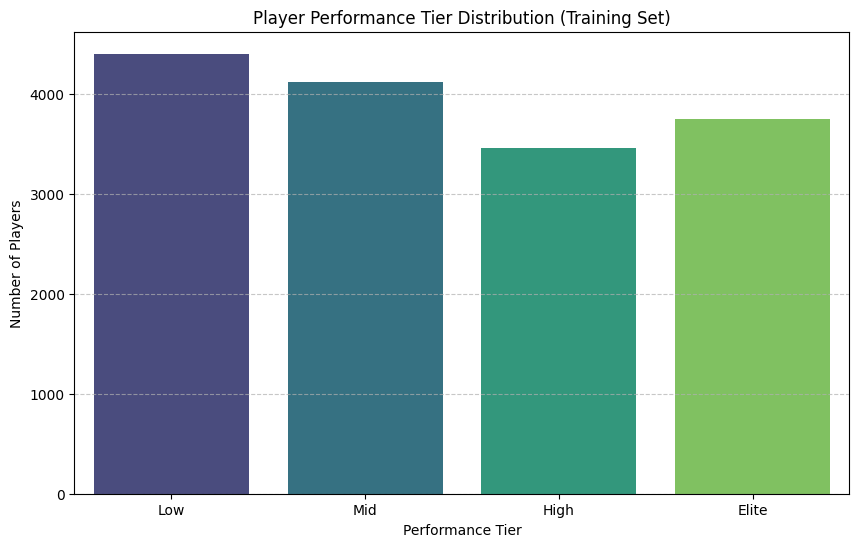


Justification: Thresholds were set at 58.00, 63.00, and 68.00 representing the 25th, 50th, and 75th percentiles of the Overall Rating. This ensures a perfectly balanced classification task where each tier has a statistically identical amount of players.


In [5]:
# 1. Load raw data for Task 3
df_task3 = pd.read_csv('Fifa.csv')

# 2. Split the data FIRST (80/20) to prevent data leakage
X = df_task3.drop(columns=['Overall_Rating'])
y = df_task3['Overall_Rating'] # y holds our target values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Calculate thresholds strictly on the Training Set 
thresholds = y_train.quantile([0.25, 0.5, 0.75]).values

# 4. Define the mapping function
def assign_tier(rating):
    if rating <= thresholds[0]:
        return 'Low'
    elif rating <= thresholds[1]:
        return 'Mid'
    elif rating <= thresholds[2]:
        return 'High'
    else:
        return 'Elite'

# 5. Apply the function to create our new categorized targets
y_train_tier = y_train.apply(assign_tier)
y_test_tier = y_test.apply(assign_tier)

# 6. Show how many players fall into each category
print("--- Class Distribution after Splitting ---")
print("Training Set:\n", y_train_tier.value_counts())
print("\nTesting Set:\n", y_test_tier.value_counts())

# 7. Plot the Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train_tier, order=['Low', 'Mid', 'High', 'Elite'], palette='viridis')
plt.title('Player Performance Tier Distribution (Training Set)')
plt.xlabel('Performance Tier')
plt.ylabel('Number of Players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 8. Justification Printout
print(f"\nJustification: Thresholds were set at {thresholds[0]:.2f}, {thresholds[1]:.2f}, and {thresholds[2]:.2f} "
      "representing the 25th, 50th, and 75th percentiles of the Overall Rating. "
      "This ensures a perfectly balanced classification task where each tier has a statistically identical amount of players.")

                 Name Country Position  Age  Overall_Rating  Future Potential  \
0  Agostinho Mabululu  Angola       LW   30              68                68   
1     Mahmoud Gennesh   Egypt       GK   35              67                67   
2      Sobhi Suleiman   Egypt       GK   28              63                65   
3        Mahmoud Alaa   Egypt       CB   32              68                68   
4     Mahmoud Shabana   Egypt       CB   30              66                66   

                 Team  Value Per M$  Total_Stats Score  
0  Ittihad Alexandria          0.65               1660  
1  Ittihad Alexandria          0.35               1620  
2  Ittihad Alexandria          0.20               1480  
3  Ittihad Alexandria          0.50               1695  
4  Ittihad Alexandria          0.40               1640  
✅ Classification Preprocessing Complete: Binned Target, OHE applied, Leakage prevented.

🔎 DATA VALIDATION CHECKS
ComplementNB Data (Non-Negative)  : ✅ PASSED
BernoulliNB 

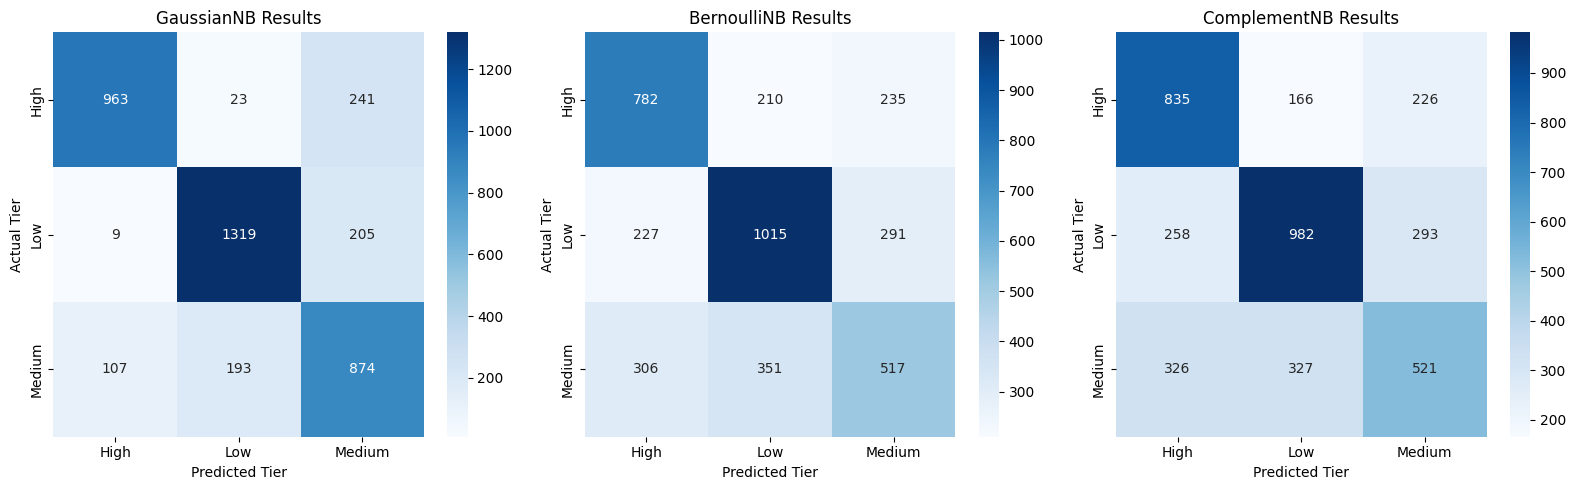

----------------------------------------
⚖️ SCALING SENSITIVITY TEST (GaussianNB)
----------------------------------------
Base Accuracy (MinMax / Unscaled): 0.8022
StandardScaled Accuracy          : 0.8022
Conclusion: Scaling does NOT affect Naive Bayes performance.


In [6]:
clf_pipeline = FIFA_Preprocessing('Fifa.csv', target_col='Performance_Tier', task_type='classification')
clf_pipeline.load_data()
X_train_clf, X_test_clf, y_train_clf, y_test_clf = clf_pipeline.prepare_data()

# 2. Create Feature Subsets for Specific Models
# A. Numerical Subset (For GaussianNB)
num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
X_train_num = X_train_clf[num_cols]
X_test_num = X_test_clf[num_cols]

# B. Strictly Binary Subset (For BernoulliNB)
binary_cols = [col for col in X_train_clf.columns if col not in num_cols]
X_train_binary = X_train_clf[binary_cols]
X_test_binary = X_test_clf[binary_cols]

# 3. Data Validation Checks (Proving our Preprocessing Worked)
print("\n" + "="*40)
print("🔎 DATA VALIDATION CHECKS")
print("="*40)

# Check A: ComplementNB needs non-negative values
min_val = X_train_clf.min().min()
is_non_negative = min_val >= 0
print(f"ComplementNB Data (Non-Negative)  : {'✅ PASSED' if is_non_negative else '❌ FAILED'}")

# Check B: BernoulliNB needs strictly 0s and 1s
is_strictly_binary = X_train_binary.isin([0, 1]).all().all()
print(f"BernoulliNB Data (Strictly Binary): {'✅ PASSED' if is_strictly_binary else '❌ FAILED'}")
print("="*40 + "\n")

# 4. Map Models to their Validated Datasets
nb_models = {
    "GaussianNB": (GaussianNB(), X_train_num, X_test_num),
    "BernoulliNB": (BernoulliNB(), X_train_binary, X_test_binary),
    "ComplementNB": (ComplementNB(), X_train_clf, X_test_clf)
}

# 5. Train, Evaluate, and Plot
print("📊 MODEL EVALUATION METRICS")
print("-" * 40)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, (model, X_train, X_test)) in enumerate(nb_models.items()):
    ax = axes[idx]
    
    # Train and Predict
    model.fit(X_train, y_train_clf)
    y_pred = model.predict(X_test)
    
    # Calculate and Print Metrics
    acc = accuracy_score(y_test_clf, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test_clf, y_pred, average='weighted', zero_division=0)
    print(f"[{name}]")
    print(f"Accuracy : {acc:.4f} | Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f} | F1-Score : {f1:.4f}\n")
    
    # Draw Confusion Matrix Heatmap
    cm = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=model.classes_, yticklabels=model.classes_)
    ax.set_title(f'{name} Results')
    ax.set_xlabel('Predicted Tier')
    ax.set_ylabel('Actual Tier')

plt.tight_layout()
plt.show()

# 6. Scaling Sensitivity Test for GaussianNB
print("-" * 40)
print("⚖️ SCALING SENSITIVITY TEST (GaussianNB)")
print("-" * 40)

# Scale the data using StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_num)
X_test_std = scaler.transform(X_test_num)

# Train Base Model (Unscaled)
gnb_base = GaussianNB()
gnb_base.fit(X_train_num, y_train_clf)
acc_base = accuracy_score(y_test_clf, gnb_base.predict(X_test_num))

# Train Scaled Model
gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_std, y_train_clf)
acc_scaled = accuracy_score(y_test_clf, gnb_scaled.predict(X_test_std))

print(f"Base Accuracy (MinMax / Unscaled): {acc_base:.4f}")
print(f"StandardScaled Accuracy          : {acc_scaled:.4f}")
print("Conclusion: Scaling does NOT affect Naive Bayes performance.")

Task 4 Polynomial Regression:

In [7]:
X_train, X_test, y_train, y_test = eda.prepare_data()

# we train the Linear Regression model on the preprocessed training data for the regression task.
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train) 

# we evaluate the model's performance on the test set using R² score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE) and MSE.
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error
mse = mean_squared_error(y_test, reg.predict(X_test))
mae = mean_absolute_error(y_test, reg.predict(X_test))
rmse = np.sqrt(mse)
r2 = r2_score(y_test, reg.predict(X_test))
print(f"R² Score: {r2:.4f}\n MAE: {mae:.4f}\n RMSE: {rmse:.4f}\n MSE: {mse:.4f}")

# Now i want know if the model is doing okay or not, so i will check the average value of the target
print(f"Average Value Per M$ in Test Set: {y_test.mean():.4f}")
# The average of the target value is 2.6 and the RMSE is 5.8021 then the model is performing poorly

✅ Regression Preprocessing Complete: Target Encoded, Outliers Capped, Scaled.
R² Score: 0.4573
 MAE: 2.4316
 RMSE: 5.8021
 MSE: 33.6644
Average Value Per M$ in Test Set: 2.6102


Degree 2 | Train R²: 0.7897 | Test R²: 0.7394
Degree 3 | Train R²: 0.9169 | Test R²: 0.8554
Degree 4 | Train R²: 0.9617 | Test R²: 0.8024


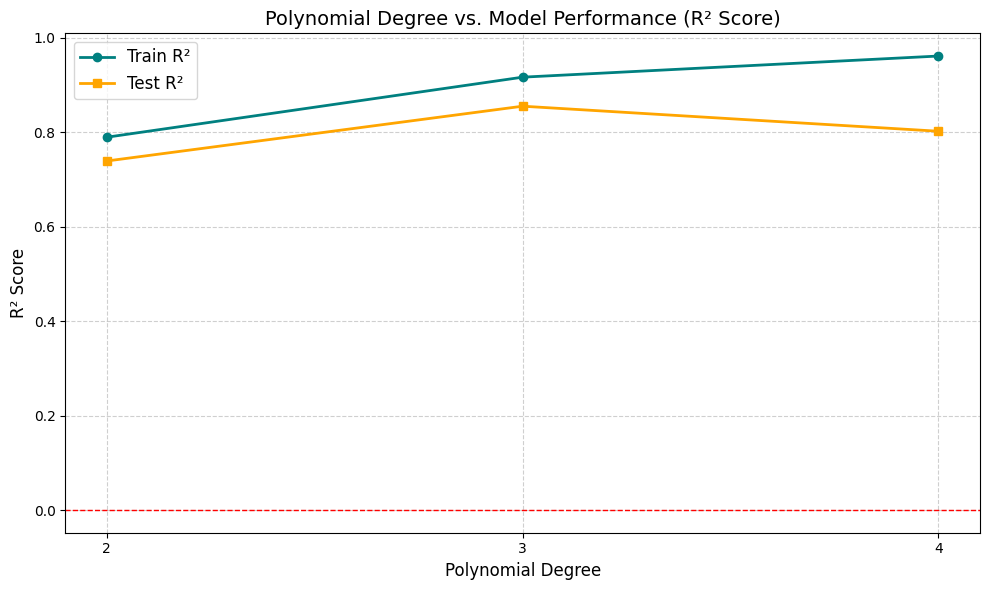

"\nwe will use the 3rd degree cuz it's the optimal solution and it avoids overfitting\n"

In [8]:
# We need to make the polynomial regresion
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

train_r2_scores = []
test_r2_scores = []

degrees = range(2, 5)

# For us to know what degree we need we will use try every degree from 2 to 4
for i in degrees:
    # Transform the dataset into polynomial features
    poly = PolynomialFeatures(degree=i)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train the linear regression model on the polynomial features
    reg.fit(X_train_poly, y_train)

    train_pred = reg.predict(X_train_poly)
    test_pred = reg.predict(X_test_poly)

    # R2 score for train and test
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    # Record scores
    train_r2_scores.append(train_r2)
    test_r2_scores.append(test_r2)

    print(f"Degree {i} | Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_r2_scores, label='Train R²', marker='o', color='teal', linewidth=2)
plt.plot(degrees, test_r2_scores, label='Test R²', marker='s', color='orange', linewidth=2)

plt.title('Polynomial Degree vs. Model Performance (R² Score)', fontsize=14)
plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.xticks(degrees)
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Baseline reference at 0
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

'''
we will use the 3rd degree cuz it's the optimal solution and it avoids overfitting
'''


In this step, we used Polynomial Regression to capture the non-linear relationship between the player's features and their value. We determined in the previous step that a **Degree 3** polynomial provides the optimal balance, maximizing our Test R² while avoiding severe overfitting.

### 4.1. Expanding Features to Degree 3
First, we mathematically expand our training and testing features to include polynomial combinations up to the 3rd degree.
```python
from sklearn.preprocessing import PolynomialFeatures

# Create the PolynomialFeatures object set to Degree 3
poly = PolynomialFeatures(degree=3)

# Fit the transformer to the training data and transform it
X_train_poly = poly.fit_transform(X_train)

# Transform the testing data using the rules learned from the training data
X_test_poly = poly.transform(X_test)

The widening gap you see between the Train R² (teal line) and Test R² (orange line)—especially as it explodes at Degree 4—is the visual definition of Overfitting.

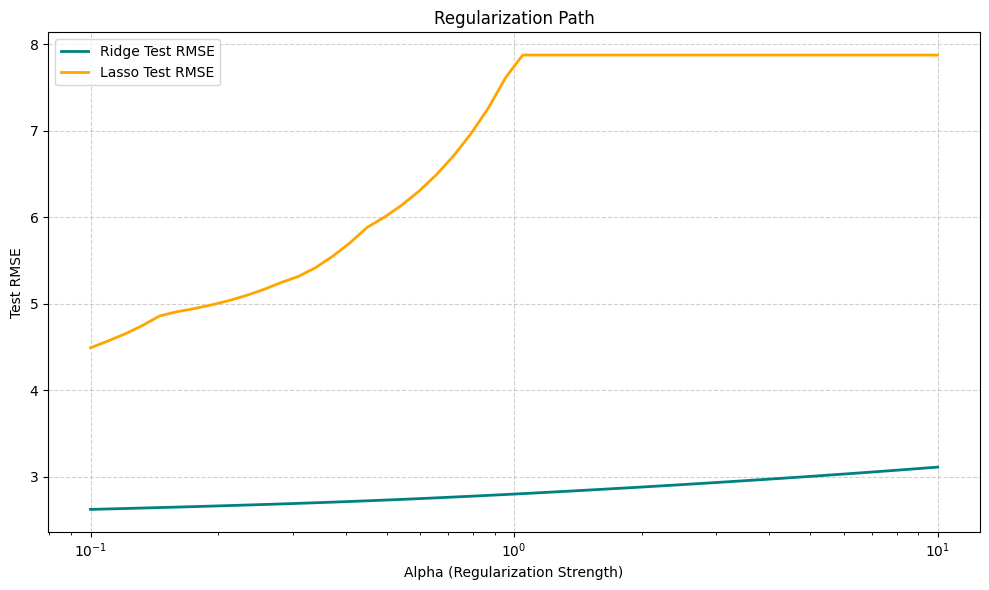

In [9]:
from sklearn.linear_model import Ridge, Lasso
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# 1. Define a log-spaced range of alphas (e.g., from 0.001 to 1000)
alphas = np.logspace(-1, 1, 50)

ridge_test_rmse, lasso_test_rmse = [], []

# 2. Sweep over alphas for Ridge and Lasso
for a in alphas:
    # Ridge (L2)
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_poly, y_train)
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_poly))))
    
    # Lasso (L1) - increased max_iter to prevent convergence warnings
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_poly, y_train)
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_poly))))

# 3. Find the best alphas (minimum Test RMSE)
best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

# 4. Plot the Curves
plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_test_rmse, label='Ridge Test RMSE', color='teal', linewidth=2)
plt.plot(alphas, lasso_test_rmse, label='Lasso Test RMSE', color='orange', linewidth=2)
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Test RMSE')
plt.title('Regularization Path')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [10]:
# 1. Train final optimal models
best_ridge = Ridge(alpha=best_ridge_alpha).fit(X_train_poly, y_train)
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000).fit(X_train_poly, y_train)

# Calculate final Train and Test RMSE
ridge_train_rmse = np.sqrt(mean_squared_error(y_train, best_ridge.predict(X_train_poly)))
ridge_test_rmse_val = np.min(ridge_test_rmse)

lasso_train_rmse = np.sqrt(mean_squared_error(y_train, best_lasso.predict(X_train_poly)))
lasso_test_rmse_val = np.min(lasso_test_rmse)

print("--- REGULARIZATION RESULTS ---")
print(f"RIDGE (L2) - Train RMSE: {ridge_train_rmse:.4f} | Test RMSE: {ridge_test_rmse_val:.4f}")
print(f"LASSO (L1) - Train RMSE: {lasso_train_rmse:.4f} | Test RMSE: {lasso_test_rmse_val:.4f}\n")

# 2. Check for Zeroed Features in Lasso
feature_names = poly.get_feature_names_out()
lasso_coefs = best_lasso.coef_
zeroed_features = feature_names[lasso_coefs == 0]

print("--- LASSO FEATURE SELECTION ---")
print(f"Total features evaluated: {len(feature_names)}")
print(f"Features zeroed out by Lasso: {len(zeroed_features)}")
print(f"Features retained: {len(feature_names) - len(zeroed_features)}")

# Print the first 10 zeroed features as an example
if len(zeroed_features) > 0:
    print(f"Sample of zeroed features: {zeroed_features[:10]}")

--- REGULARIZATION RESULTS ---
RIDGE (L2) - Train RMSE: 1.8235 | Test RMSE: 2.6210
LASSO (L1) - Train RMSE: 3.7176 | Test RMSE: 4.4911

--- LASSO FEATURE SELECTION ---
Total features evaluated: 330
Features zeroed out by Lasso: 326
Features retained: 4
Sample of zeroed features: ['1' 'Country' 'Position' 'Age' 'Overall_Rating' 'Future Potential' 'Team'
 'Total_Stats Score' 'Country^2' 'Country Position']


In [14]:
feature_names[lasso_coefs != 0]

array(['Age^3', 'Overall_Rating^3 Future Potential',
       'Overall_Rating^3 Team', 'Overall_Rating^2 Future Potential^2'],
      dtype=object)